# check Langleys

In [1]:
import atmPy.radiation.retrievals.langley_calibration as atmlc
import atmPy.radiation.retrievals.spectral_irradiance as atmspec
import atmPy.aerosols.physics.column_optical_properties as atmcop
import helpers

In [3]:
reload(atmspec)
reload(atmspec.atmlangcalib)

<module 'atmPy.radiation.retrievals.langley_calibration' from '/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/langley_calibration.py'>

In [4]:
prefix = '/Users/htelg'
version = '0.5' #this is wehere the langleys go
version_in = '0.2'
serialno = 648
"""
changes
-------
0.5 
- improved cosine-correction
0.4
- improved airmass
- improved coordinates and included altitude
0.3
- use cloud screening for cleaning
- removed 940 nm channel in langley cleaning!
0.2
- langleys out to 5 atm
"""
p2fld_lang = f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.langleys/v{version}'
p2fld_lang

'/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.5'

## 648

In [5]:
reload(atmlc)

<module 'atmPy.radiation.retrievals.langley_calibration' from '/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/langley_calibration.py'>

In [6]:
p2fld = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.langleys/v{version}/')
lt = atmlc.open_langleys(p2fld)
lt_pre_648 = lt

Text(0.5, 1.0, '1625')

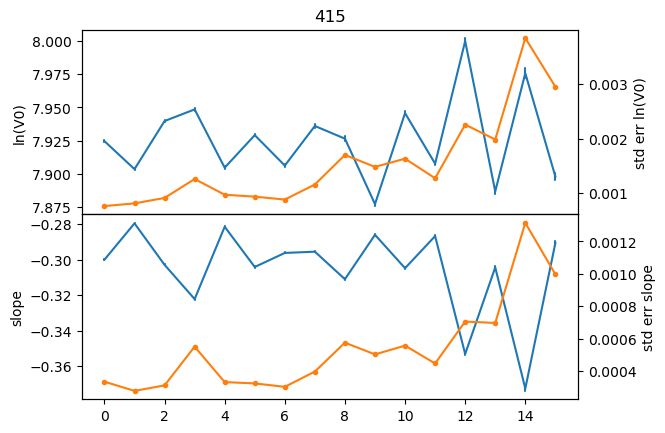

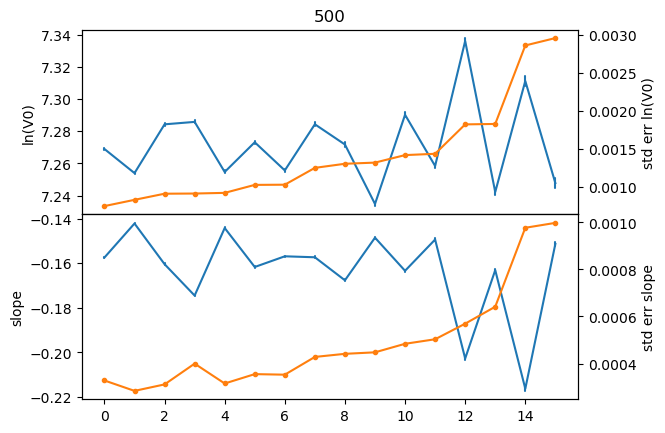

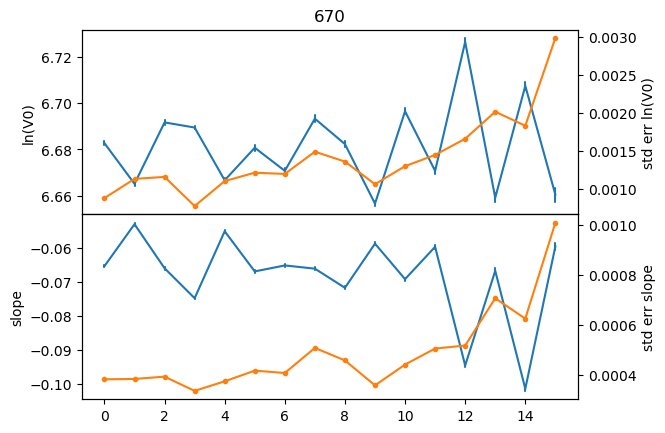

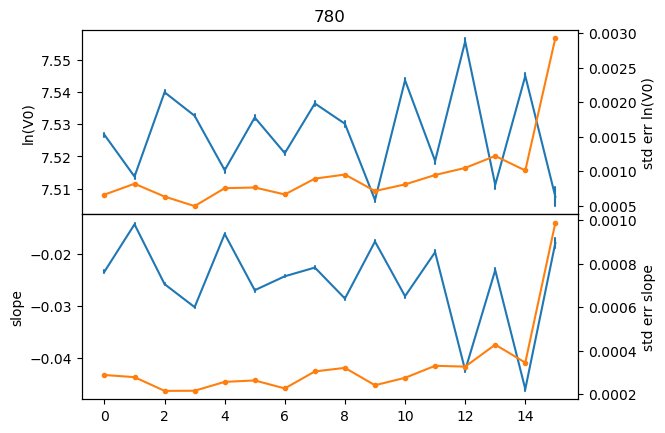

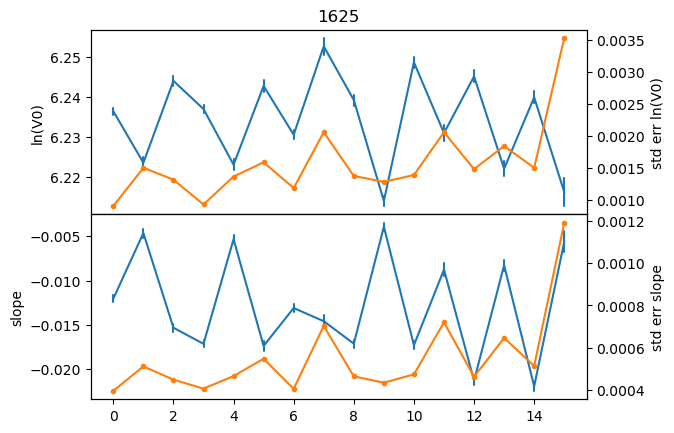

In [7]:
f,a = lt.plot_sorted(wl = 415, wlsort=500)
a[0].set_title('415')
f,a = lt.plot_sorted(wl = 500)
a[0].set_title('500')
f,a = lt.plot_sorted(wl = 670, wlsort=500)
a[0].set_title('670')
f,a = lt.plot_sorted(wl = 870, wlsort=500)
a[0].set_title('780')
f,a = lt.plot_sorted(wl = 1625, wlsort=500)
a[0].set_title('1625')

In [8]:
lt.V0_simple

<xarray.Dataset> Size: 336B
Dimensions:                              (wavelength: 6)
Coordinates:
  * wavelength                           (wavelength) int64 48B 415 500 ... 1625
Data variables:
    V0                                   (wavelength) float64 48B 2.769e+03 ....
    V0_std                               (wavelength) float64 48B 89.83 ... 5.95
    no_langleys                          (wavelength) int64 48B 16 16 ... 16 16
    one_sided_upper_bound_factor_95conf  (wavelength) float64 48B 1.437 ... 1...
    OD_uncertainty                       (wavelength) float64 48B 0.05163 ......
    V0_stderr                            (wavelength) float64 48B 0.001554 .....

# create Langles

In [9]:
import atmPy.radiation.retrievals.spectral_irradiance as atmspir

## 648

In [10]:
version_in = '0.2' # this is the version of the mfrsr calibrated data
# serialno = 648
lt = lt_pre_648 #None
p2fld = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025')

In [11]:
p2flist = list(p2fld.glob('*'))
p2flist.sort()

In [12]:
p2flist

[PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250925.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250926.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250927.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250928.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250929.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250930.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20251001.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_2025100

In [13]:
'/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_cosinecorrected_20251018.nc'

'/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_cosinecorrected_20251018.nc'

### 20251017

In [14]:
%matplotlib inline

In [15]:
date = '1017'
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

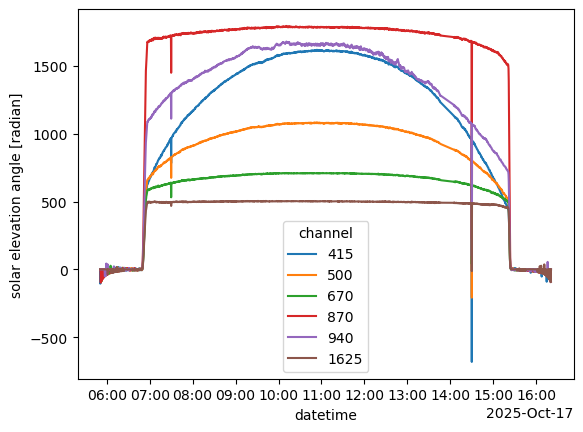

In [16]:
# first glance
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime')

In [17]:
lang_am, lang_pm = helpers.get_langleys(ds, fnmet, 
                                        lt,
                                        # None,
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                       )
# when there are 
if 0:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: invalid value encountered in log
  result_data = func(*input_data)
/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/spectral_irradiance.py:1645: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ds['co2'] = xr.DataArray(np.zeros(tuple(self.dataset.dims[d] for d in ['datetime', 'channel'])),
/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/spectral_irradiance.py:1170: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ozon2bychannel = ozon2bychannel.drop('wavel

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

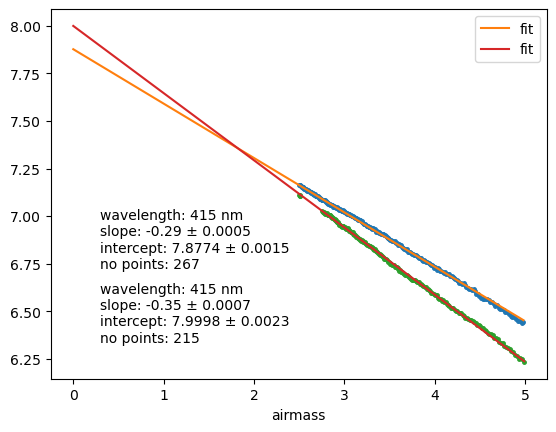

In [18]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

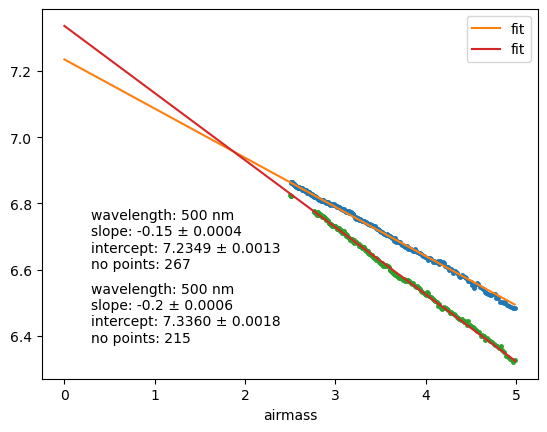

In [19]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

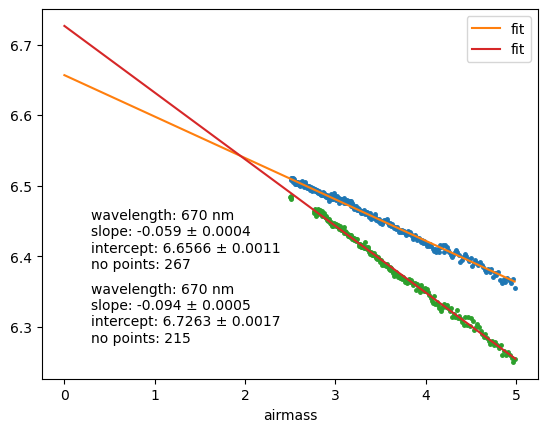

In [20]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

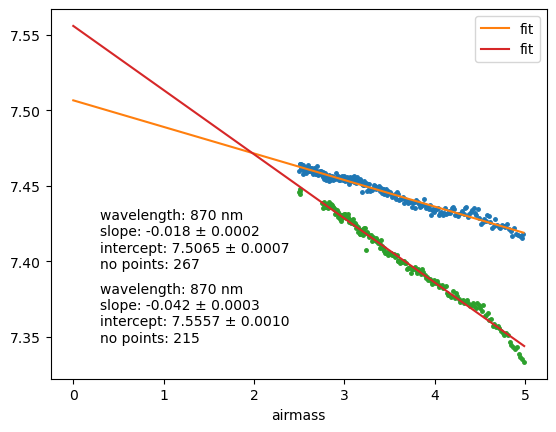

In [21]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

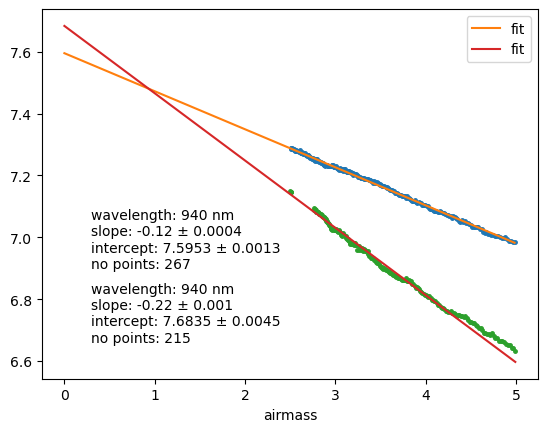

In [22]:
wl = 940
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

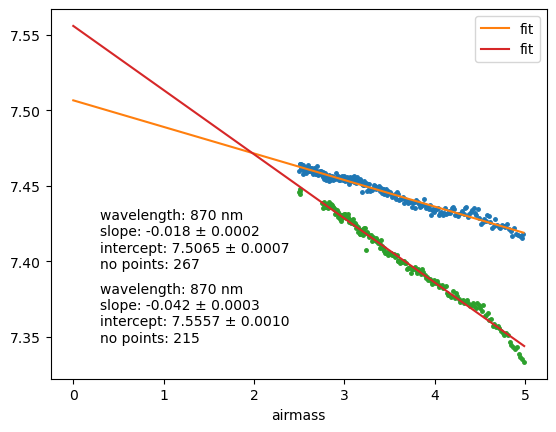

In [23]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

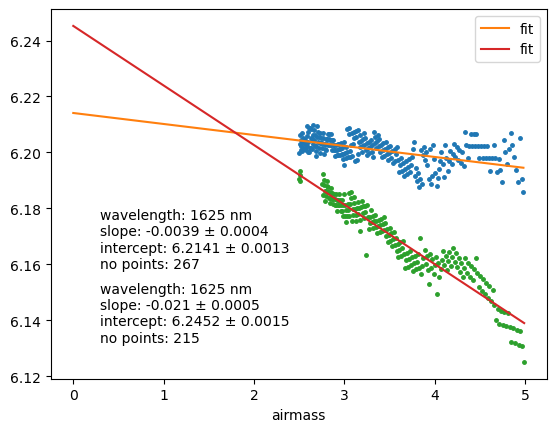

In [24]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

# What about 940

[bob's opinion](https://chatgpt.com/g/g-p-67b6018b33448191859813562bab6644-programming-help/c/6a29f63b-9f68-83e8-a972-a4937f6709e8)

My goal is to find the top of the atmosphere intensity $I_0$ which for the 940 nm channel is dominated by the  molecular transmittend $T_{R}$ (Rayleigh-scattering), aerosol $T_{A}$, and precipitable water vapor $T_{pwv}$. The measured intensity $I$ is therefore given by, 
$$
I = I_0 ~ T_{R} ~ T_{A} ~ T_{pwv}
$$
here T_{R} and T_{A} are known, we can therfore write:
$$
I_{R,A} = \frac{I}{T_{R}~T_{A}} = I_0 ~ e^{-\tau_{pwv}}
$$
On a clear-sky day (typically just halfday am/pm) with little change in pwv over time and a look-up-table for the pwv optical depth:
$$
\tau_{pwv} = lut(pwv, AMF)
$$
where AMF is the airmass factor, we can write
$$
I_{R,A}(AMF) =I_0 ~ e^{-lut(pwv, AMF)}
$$
To determin the unknowns we will optimimize the expression above for $pwv$ and $I_0$

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import atmPy.radiation.retrievals.spectral_irradiance as atmspec
import atmPy.radiation.retrievals.langley_calibration as atmlc
from scipy.optimize import minimize_scalar
import helpers

In [4]:
import scipy as sp

In [5]:
sp.optimize.minimize_scalar

<function scipy.optimize._minimize.minimize_scalar(fun, bracket=None, bounds=None, args=(), method=None, tol=None, options=None)>

In [6]:
%matplotlib inline

In [7]:
prefix = '/Users/htelg'
version_in = '0.2'
date = '1017'
serialno = 648
version_lang = '0.5' 
verbose = True
ampm = 'am'
amf_range = (2.5, 4.5)

# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'
p2langs = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.langleys/v{version_lang}/')
fnlut = f'/Users/htelg/projects/mfrsr2pwv/data/pwd_od_lut_{serialno}.nc'


In [82]:
out = {}
# load files
ds = xr.open_dataset(p2f)
dsmet = xr.open_dataset(fnmet)
dslang = atmlc.open_langleys(p2langs) #these are past langleys for cloud detection purposes
ds_lut = xr.open_dataset(fnlut)
ds_lut = ds_lut.rename({'air_mass': 'airmass'})
ds_lut.attrs.update({'path2file': fnlut})

out['ds_original'] = ds.copy()
out['dsmet'] = dsmet

In [132]:
reload(helpers)

lt = dslang
out = helpers.get_langleys(ds, fnmet, 
                            lt,
                            # None,
                            langley_airmass_limits=amf_range,
                            # clean = False,
                            # clean = 'normal',
                            clean = 'cloudscreening',
                           ds_lut = ds_lut
                                       )

/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: invalid value encountered in log
  result_data = func(*input_data)
/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/spectral_irradiance.py:1645: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ds['co2'] = xr.DataArray(np.zeros(tuple(self.dataset.dims[d] for d in ['datetime', 'channel'])),
/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/spectral_irradiance.py:1170: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ozon2bychannel = ozon2bychannel.drop('wavel

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/htelg/prog/atm-py/atmPy/radiation/rayleigh/lab.py:132: RuntimeWarning: divide by zero encountered in divide
  sigma_um_inv = 1.0 / lam_um
/Users/htelg/prog/atm-py/atmPy/radiation/rayleigh/lab.py:168: RuntimeWarning: divide by zero encountered in divide
  sigma_R = (24.0 * np.pi**3 / (lam_m**4 * N_s**2)) * term * F_K
/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/spectral_irradiance.py:1170: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ozon2bychannel = ozon2bychannel.drop('wavelength')
/Users/htelg/miniconda3/envs/py13/li

In [133]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

In [139]:
outclean = pwvcal_am.clean(threshold=1.7)

skewness: 0.1815	 skewscale:2.2246
skewness: 0.1762	 skewscale:2.2092


In [140]:
pwvcal_amc = outclean['pwvcal']

(1108.0047633949675, 1600.0)

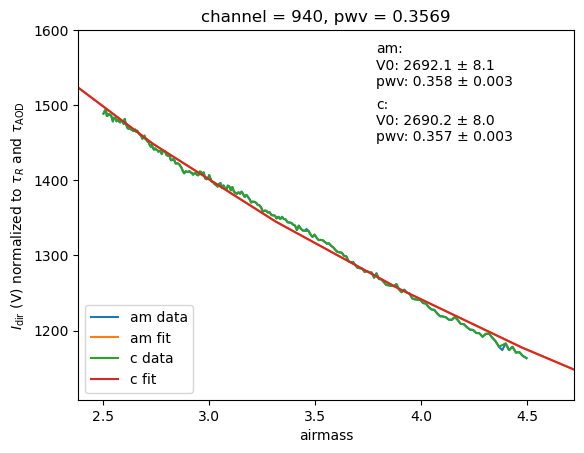

In [141]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_amc.plot(ax = a, label='c', textpos=(0.6,0.7))
a.set_ylim(top = 1600)

In [108]:
pwvcal_am.residual.dropna('airmass').shape

(240,)

In [112]:
pwvcal_am.residual.sum()

<xarray.DataArray ()> Size: 8B
array(-2.14284476)
Coordinates:
    channel  int64 8B 940
    pwv      float64 8B 0.3575
Attributes:
    corrected_for_rayleigh:     True
    corrected_for_ozone:        True
    corrected_for_co2_ch4_h2o:  False
    long_name:                  optical_depth

(828.2221637880821, 1600.0)

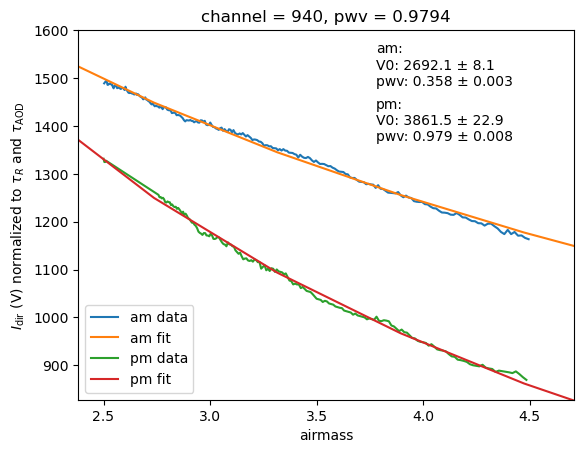

In [91]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1600)

In [62]:
pwvcal_am.fit

<xarray.DataArray 'optical_depth' (airmass: 20)> Size: 160B
array([1919.2827993 , 1722.50024284, 1571.5820752 , 1448.58861023,
       1344.8818216 , 1255.67068407, 1177.41857899, 1108.05787561,
       1045.74177823,  989.84599747,  938.76410038,  892.39859844,
        850.0608657 ,  811.31813121,  775.36617911,  741.9609578 ,
        710.68395208,  681.92375596,  655.06213831,  630.38939384])
Coordinates:
  * airmass             (airmass) float64 160B 1.0 1.579 2.158 ... 11.42 12.0
    solar_zenith_angle  (airmass) float64 160B ...
    channel             int64 8B ...
    pwv                 float64 8B 0.3575
Attributes:
    long_name:  optical_depth
    units:      1

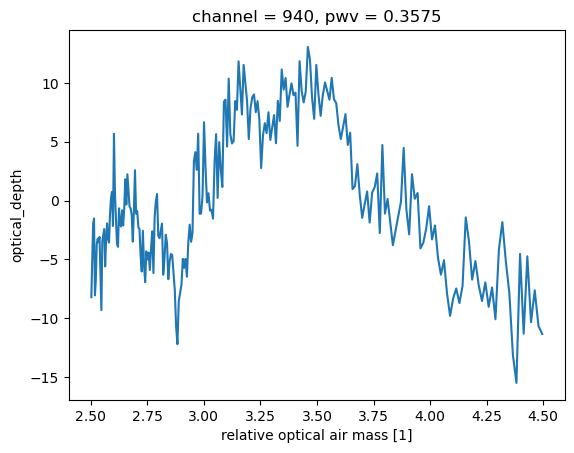

In [64]:
pwvcal_am.residual.plot()

In [70]:
pwvcal_am.residual.std()/pwvcal_am.fit_match_data_airmasses.mean()

<xarray.DataArray ()> Size: 8B
array(0.0044478)
Coordinates:
    channel  int64 8B 940
    pwv      float64 8B 0.3575
Attributes:
    corrected_for_rayleigh:     True
    corrected_for_ozone:        True
    corrected_for_co2_ch4_h2o:  False
    long_name:                  optical_depth
    units:                      1

In [69]:
pwvcal_am.fit_match_data_airmasses.mean()

<xarray.DataArray 'optical_depth' ()> Size: 8B
array(1360.93009703)
Coordinates:
    channel  int64 8B ...
    pwv      float64 8B 0.3575
Attributes:
    long_name:  optical_depth
    units:      1

In [80]:
df = pd.concat([pd.DataFrame(pwvcal_am.fitres, index = ['extimate']),
           pd.DataFrame(pwvcal_am.fitres, index = ['uncertainty'])])
df.columns.name = 'parameter'

In [81]:
df

parameter,V0,pwv
extimate,2692.13044,0.357524
uncertainty,2692.13044,0.357524


In [73]:
pwvcal_am.fitres_uncertainty

{'V0': np.float64(8.109088770906402), 'pwv': np.float64(0.002610898069599471)}

In [ ]:
pwvcal_am.

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'channel = 940, pwv = 0.3575'}, xlabel='air_mass', ylabel='$I_\\mathrm{dir}$ (V) normalized to $\\tau_R$ and $\\tau_\\mathrm{AOD}$'>)

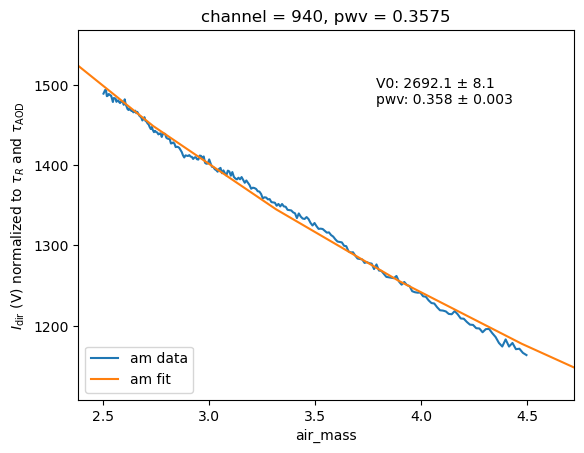

In [25]:
pwvcal_am.plot(label='am')

In [ ]:
xr.open_dataset

In [7]:
out

{'sir': <atmPy.radiation.retrievals.spectral_irradiance.DirectNormalIrradiation at 0x30cbfd400>,
 'dnic': <atmPy.radiation.retrievals.spectral_irradiance.DirectNormalIrradiation at 0x30cc11d10>,
 'aodi': <atmPy.aerosols.physics.column_optical_properties.AOD_AOT at 0x30cbfde80>,
 'cloudmask': <xarray.DataArray 'cloudy' (datetime: 4267)> Size: 34kB
 array([nan, nan, nan, ..., nan, nan, nan], shape=(4267,))
 Coordinates:
   * datetime  (datetime) datetime64[ns] 34kB 2025-10-17 ... 2025-10-17T23:59:40,
 'langley_am': <atmPy.radiation.retrievals.langley_calibration.Langley at 0x30cbfe270>,
 'langley_pm': <atmPy.radiation.retrievals.langley_calibration.Langley at 0x30cc11e50>}

In [8]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']
sir = out['sir']

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

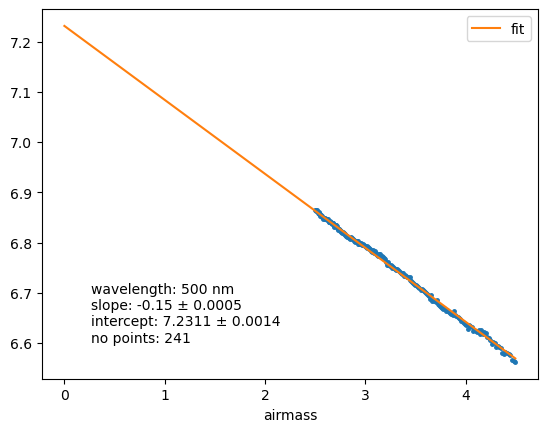

In [9]:
lang_am.plot(wavelength=500)

In [10]:
# First perform a langley calibration
# greate the instance
# gdd = atmspec.CombinedGlobalDiffuseDirect(ds.copy(), verbose = verbose)
# gdd.dataset['channel_wavelength'] = gdd.dataset.channel_wavelength.astype(float) #error in processing upstream, fix it in future versions!

if ampm == 'am':
    lang = lang_am
else:
    lang = lang_pm

langts = atmlc.open_langleys([lang.to_xarray_dataset()])

In [15]:
# now get the pwv calibretion
class PwvCalibration940(object):
    def __init__(self):
        return

    def plot(self):
        tau_pwv = self.lookuptable.interp(pwv = self.fitres['pwv']).optical_depth
        fit = self.fitres['V0'] * np.exp(-tau_pwv)
        f,a = plt.subplots()
        self.normalized_direct_normal.plot(ax = a)
        fit.plot(ax = a)
        a.set_xlim(-1, 6)
        pad = 1.05
        ymin = self.normalized_direct_normal.min() * 1/pad
        ymax = self.normalized_direct_normal.max() * pad 
        a.set_ylim(ymin, ymax)
        xmin = self.normalized_direct_normal.airmass.min() * 1/pad
        xmax = self.normalized_direct_normal.airmass.max() * pad
        a.set_xlim(xmin, xmax)
        # ylabel = r"Direct normal normalized to $\tau_{R}$ and $\tau{AOD}$"
        ylabel = r"Normalized $I_\mathrm{dir}$"
        ylabel = r"$I_\mathrm{dir}$ (V) normalized to $\tau_R$ and $\tau_\mathrm{AOD}$"
        a.set_ylabel(ylabel)
        txt = (f'V0: {self.fitres["V0"]:0.1f} ± {self.fitres_uncertainty["V0"]:0.1f}\n'
               f'pwv: {self.fitres["pwv"]:0.3f} ± {self.fitres_uncertainty["pwv"]:0.3f}')
        a.text(0.6, 0.8, txt, transform = a.transAxes)
        return f,a

def determine_940_calcoeffs(ds, langts, dsmet, ozone, ds_lut):
    # todo: test all units
    out = {}
    gdd = atmspec.CombinedGlobalDiffuseDirect(ds.copy(), verbose = verbose)
    # apply langleys
    gdd = gdd.apply_calibration_langley(langts)

    ### Moving to direct
    dni = gdd.direct_normal_irradiation
    dni.dataset.attrs['serial_no'] = dni.dataset.sn_mfrsr # todo: this test should not be happening here, but in an external processing step (in surfradpy?)
    out['dni_inst'] =  dni

    # met data
    dni.met_data = dsmet

    # ozone
    # dni.ozone_data = 300
    ozone = ozone.where(ozone != -99.999)
    ozone = ozone.interpolate_na('time', method = 'nearest', fill_value = 'extrapolate')
    dni.ozone_data = ozone

    dni.skip_1625_channel = True

    dni.aod
    

    #extrapolate to get aod at 940 
    #todo, this needs to be added to the retrieval
    
    l1 =  500
    l2 = 870
    t1 = dni.aod.sel(channel = l1)
    t2 = dni.aod.sel(channel = l2)
    t1 = t1.where(t1>0, other = 0.001)
    t2 = t2.where(t2>0, other = 0.001)
    ang = - np.log(t1/t2)/np.log(l1/l2)
    l3 = 940
    t3 = t1 * (l3/l1)**-ang
    
    dni.aod.loc[dict(channel = 940)] = t3
    
    wl = 940
    dst = dni.dataset.copy()
    dst['direct_normal_raw'] = ds.direct_normal
    dst = dst.sel(channel = wl)
    dst = dst.swap_dims({'datetime':'airmass'})
    dst = dst.sortby('airmass')
    
    
    
    assert(dst.solar_azimuth_angle.units == 'degrees')
    
    if ampm == 'pm':
        dst = dst.where(dst.solar_azimuth_angle > 180, drop = True)
    elif ampm == 'am':
        dst = dst.where(dst.solar_azimuth_angle < 180, drop = True)
    
    dst = dst.where(np.logical_and(amf_range[0] < dst.airmass, dst.airmass < amf_range[1]), drop = True)
    
    dst = dst.where(np.isfinite(dst.airmass), drop = True)
    
    I_pwv_r = dst.direct_normal_raw/(np.exp(-dst.od_rayleigh) * np.exp(-dst.aod))
    
    assert(not (~np.isfinite(dst.od_rayleigh)).sum() > 0)
    assert(not (~np.isfinite(dst.aod)).sum() > 0)
    assert(not (~np.isfinite(dst.direct_normal)).sum() > 0)
    assert(not (~np.isfinite(I_pwv_r)).sum() > 0)
    
    x_fit = I_pwv_r.airmass.values
    I_fit = I_pwv_r.values # used to be I_fit_data ... find a better term
    lut_da = ds_lut.optical_depth
    def transmission(pwv):
        tau = lut_da.interp(air_mass=x_fit, pwv=pwv).values
        return np.exp(-tau)
    
    def best_I0_for_pwv(pwv):
        t = transmission(pwv)
        return np.sum(I_fit * t) / np.sum(t**2)
    
    def cost(pwv):
        t = transmission(pwv)
        I0 = np.sum(I_fit * t) / np.sum(t**2)
        return np.sum((I_fit - I0 * t) ** 2)
    
    res = minimize_scalar(
        cost,
        bounds=(lut_da.pwv.min().item(), lut_da.pwv.max().item()),
        method="bounded",
    )
    
    pwv_fit = res.x
    I0_fit = best_I0_for_pwv(pwv_fit)

    # get uncertainty
    tau_da = lut_da
    dtau_dpwv_da = lut_da.differentiate("pwv")
    
    def tau(pwv): #todo: this function is the same as above!!
        return tau_da.interp(air_mass=x_fit, pwv=pwv).values
    
    def dtau_dpwv(pwv):
        return dtau_dpwv_da.interp(air_mass=x_fit, pwv=pwv).values
    
    def transmission(pwv):
        return np.exp(-tau(pwv))
    
    def dtransmission_dpwv(pwv):
        t = transmission(pwv)
        return -t * dtau_dpwv(pwv)

    t = transmission(pwv_fit)
    dt = dtransmission_dpwv(pwv_fit)
    
    J = np.column_stack([
        t,
        I0_fit * dt,
    ])
    residual = I_fit - I0_fit * t
    rss = np.sum(residual**2)
    
    n = I_fit.size
    p = 2
    sigma2 = rss / (n - p)
    
    pcov = sigma2 * np.linalg.inv(J.T @ J)
    
    I0_std, pwv_std = np.sqrt(np.diag(pcov)) # these are 1 sigma!
    
    # make the instance
    pwvcal = PwvCalibration940()
    pwvcal.lookuptable = ds_lut
    pwvcal.normalized_direct_normal = I_pwv_r #todo: set attributes, units, ...
    pwvcal.fitres = dict(V0 = I0_fit,
                         pwv = res.x)
    pwvcal.fitres_uncertainty = dict(V0 = I0_std,
                         pwv = pwv_std)
    return pwvcal



    
pwvcal = determine_940_calcoeffs(sir.dataset, langts, dsmet, dsmet.ozone, ds_lut)

Applying langley calibration
--------------------------------


/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/htelg/prog/atm-py/atmPy/radiation/rayleigh/lab.py:132: RuntimeWarning: divide by zero encountered in divide
  sigma_um_inv = 1.0 / lam_um
/Users/htelg/prog/atm-py/atmPy/radiation/rayleigh/lab.py:168: RuntimeWarning: divide by zero encountered in divide
  sigma_R = (24.0 * np.pi**3 / (lam_m**4 * N_s**2)) * term * F_K
/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/spectral_irradiance.py:1170: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ozon2bychannel = ozon2bychannel.drop('wavelength')


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'channel = 940, pwv = 0.3575'}, xlabel='air_mass', ylabel='$I_\\mathrm{dir}$ (V) normalized to $\\tau_R$ and $\\tau_\\mathrm{AOD}$'>)

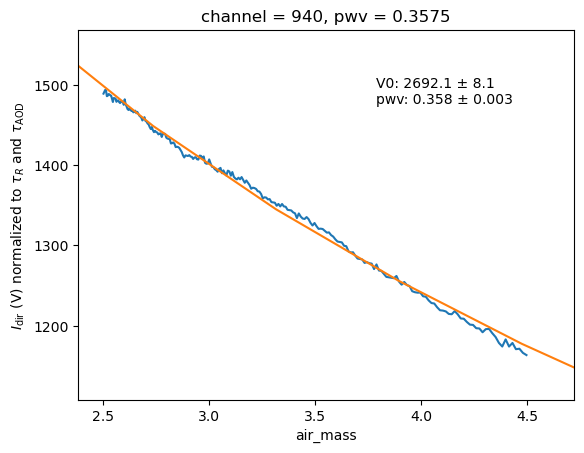

In [16]:
pwvcal.plot()

In [161]:
lut_da.interp(air_mass=2, pwv=0.2).values

array(0.36062752)

In [60]:
I_pwv_r

<xarray.DataArray (airmass: 0, channel: 6, datetime: 4267)> Size: 0B
array([], shape=(0, 6, 4267), dtype=float64)
Coordinates:
  * airmass   (airmass) float64 0B 
  * channel   (channel) int64 48B 415 500 670 870 940 1625
  * datetime  (datetime) datetime64[ns] 34kB 2025-10-17 ... 2025-10-17T23:59:40
Attributes:
    comment:                    Earth–Sun distance expressed in astronomical ...
    units:                      W/m^2/nm
    corrected_for_rayleigh:     True
    corrected_for_ozone:        True
    corrected_for_co2_ch4_h2o:  False

In [ ]:
dni.precipitable_water = ds_lut
dni.skip_1625_channel = True
dni.precipitable_water      # initiates the calculation of pwv

# reset AOD so it is calculated with 1625
dni.dataset = dni.dataset.drop_vars('aod')
dni.skip_1625_channel = False

In [26]:
fnlut = f'/Users/htelg/projects/mfrsr2pwv/data/pwd_od_lut_{serialno}.nc'
ds_lut = xr.open_dataset(fnlut)
ds_lut.attrs.update({'path2file': fnlut})

In [27]:
ds_lut

<xarray.Dataset> Size: 4kB
Dimensions:             (pwv: 20, air_mass: 20)
Coordinates:
  * pwv                 (pwv) float64 160B 0.01 0.01438 0.02069 ... 6.952 10.0
  * air_mass            (air_mass) float64 160B 1.0 1.579 2.158 ... 11.42 12.0
    solar_zenith_angle  (air_mass) float64 160B ...
    channel             int64 8B ...
Data variables:
    optical_depth       (pwv, air_mass) float64 3kB ...
Attributes:
    title:      Lookup table for precipitable water retrieval from MFRSR 940 ...
    product:    mfrsr_pwv_lut
    path2file:  /Users/htelg/projects/mfrsr2pwv/data/pwd_od_lut_648.nc

<xarray.Dataset> Size: 4kB
Dimensions:             (pwv: 20, air_mass: 20)
Coordinates:
  * pwv                 (pwv) float64 160B 0.01 0.01438 0.02069 ... 6.952 10.0
  * air_mass            (air_mass) float64 160B 1.0 1.579 2.158 ... 11.42 12.0
    solar_zenith_angle  (air_mass) float64 160B ...
    channel             int64 8B ...
Data variables:
    optical_depth       (pwv, air_mass) float64 3kB ...
Attributes:
    title:      Lookup table for precipitable water retrieval from MFRSR 940 ...
    product:    mfrsr_pwv_lut
    path2file:  /Users/htelg/projects/mfrsr2pwv/data/pwd_od_lut_648.nc

<xarray.Dataset> Size: 4kB
Dimensions:             (pwv: 20, air_mass: 20)
Coordinates:
  * pwv                 (pwv) float64 160B 0.01 0.01438 0.02069 ... 6.952 10.0
  * air_mass            (air_mass) float64 160B 1.0 1.579 2.158 ... 11.42 12.0
    solar_zenith_angle  (air_mass) float64 160B ...
    channel             int64 8B ...
Data variables:
    optical_depth       (pwv, air_mass) float64 3kB ...
Attributes:
    title:      Lookup table for precipitable water retrieval from MFRSR 940 ...
    product:    mfrsr_pwv_lut
    path2file:  /Users/htelg/projects/mfrsr2pwv/data/pwd_od_lut_648.nc

<xarray.Dataset> Size: 4kB
Dimensions:             (pwv: 20, air_mass: 20)
Coordinates:
  * pwv                 (pwv) float64 160B 0.01 0.01438 0.02069 ... 6.952 10.0
  * air_mass            (air_mass) float64 160B 1.0 1.579 2.158 ... 11.42 12.0
    solar_zenith_angle  (air_mass) float64 160B ...
    channel             int64 8B ...
Data variables:
    optical_depth       (pwv, air_mass) float64 3kB ...
Attributes:
    title:      Lookup table for precipitable water retrieval from MFRSR 940 ...
    product:    mfrsr_pwv_lut
    path2file:  /Users/htelg/projects/mfrsr2pwv/data/pwd_od_lut_648.nc

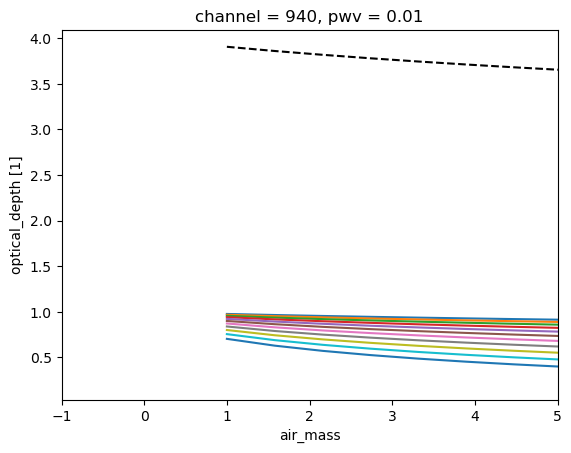

In [43]:
f,a = plt.subplots()
dst = ds_lut.where(ds_lut.pwv < 0.4)
dstt = np.exp(-dst.optical_depth)#np.log(np.exp(-dst.optical_depth))
dstt.plot.line(x = 'air_mass', add_legend = False, ax = a)
# a.axvline(0, color = 'black', ls = '--')
a.set_xlim(left = -1, right = 5)
# (4* dstt.isel(pwv = 0)).plot(ax = a, color = 'black', ls = '--')

(-1.0, 5.0)

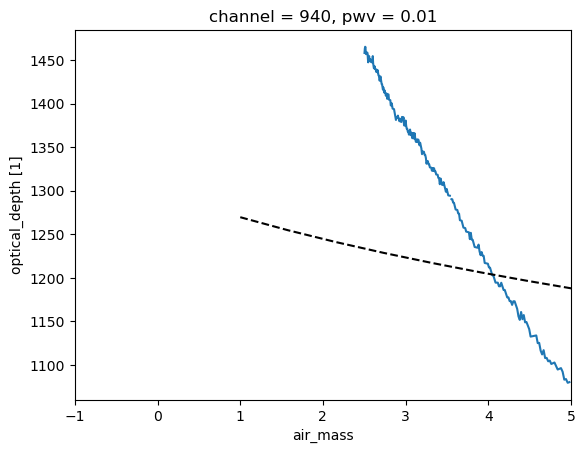

In [52]:
f,a = plt.subplots()
np.exp(lang_am.dataset.sel(channel = 940).direct_normal).plot(ax = a)
(1300* dstt.isel(pwv = 0)).plot(ax = a, color = 'black', ls = '--')
a.set_xlim(left = -1, right = 5)


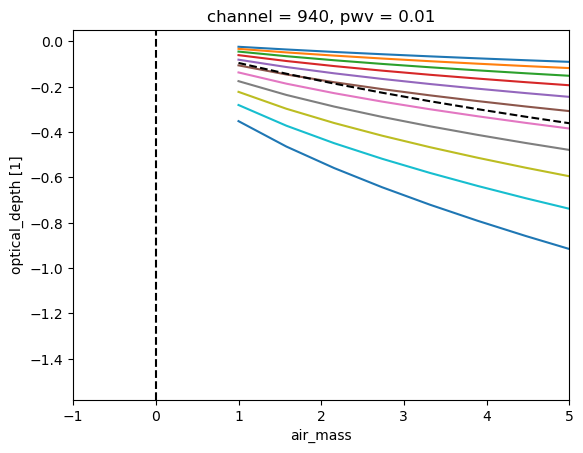

In [39]:
f,a = plt.subplots()
dst = ds_lut.where(ds_lut.pwv < 0.4)
dstt = np.log(np.exp(-dst.optical_depth))
dstt.plot.line(x = 'air_mass', add_legend = False, ax = a)
a.axvline(0, color = 'black', ls = '--')
a.set_xlim(left = -1, right = 5)
(4* dstt.isel(pwv = 0)).plot(ax = a, color = 'black', ls = '--')

In [32]:
pwv_l = dstt.isel(pwv = 0)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

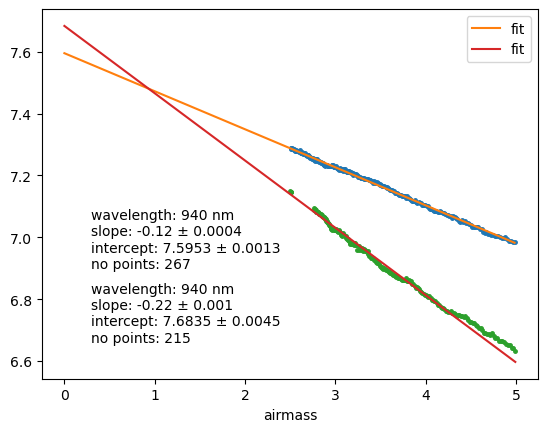

In [37]:
wl = 940
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)